In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import pandas as pd
from tqdm import tqdm

import torch
from torch.nn import CrossEntropyLoss,Linear
from torch.cuda.amp import GradScaler,autocast
from torch.utils.data import DataLoader,Dataset
from torchvision.utils import make_grid
import torchvision.transforms.v2 as v2
from torchvision.models import resnet50,ResNet50_Weights
from torch.optim import AdamW
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report


import warnings
warnings.filterwarnings('ignore')

In [ ]:
IMG_SIZE = 224

NUM_CLASSES = 2

EPOCHS = 20
BATCH_SIZE = 64

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-3

PATIENCE = 3

MEAN_NORM = [0.485, 0.456, 0.406]
STD_NORM = [0.229, 0.224, 0.225]

NUM_WORKERS = 4
PIN_MEMORY = True

LABELS = ['Bird',"Drone"]

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
class DBDataset(Dataset):
    def __init__(self,df,transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        img_path = self.df.iloc[index,0]
        label = self.df.iloc[index,1]

        img = Image.open(img_path).convert('RGB')

        if self.transforms:
            img = self.transforms(img)

        return img,label


In [ ]:
dataset_path = '/kaggle/input/datasets/abdullahbakr7/drones-vs-birds/dataset'

def prepare_dataframe(dataset_path):
    all_imgs = []
    all_labels = []

    for class_folder in os.listdir(dataset_path):
        class_idx = LABELS.index(class_folder.capitalize())
        class_path = os.path.join(dataset_path,class_folder)
        for img_item in os.listdir(class_path):
            all_imgs.append(os.path.join(class_path,img_item))
            all_labels.append(class_idx)

    df = pd.DataFrame({'Image Path': all_imgs,
                    'Image Label': all_labels})
    return df

df = prepare_dataframe(dataset_path)
df

,Image Path,Image Label
0,/kaggle/input/datasets/abdullahbakr7/drones-vs...,0
1,/kaggle/input/datasets/abdullahbakr7/drones-vs...,0
2,/kaggle/input/datasets/abdullahbakr7/drones-vs...,0
3,/kaggle/input/datasets/abdullahbakr7/drones-vs...,0
4,/kaggle/input/datasets/abdullahbakr7/drones-vs...,0
...,...,...
22037,/kaggle/input/datasets/abdullahbakr7/drones-vs...,1
22038,/kaggle/input/datasets/abdullahbakr7/drones-vs...,1
22039,/kaggle/input/datasets/abdullahbakr7/drones-vs...,1
22040,/kaggle/input/datasets/abdullahbakr7/drones-vs...,1


In [ ]:
train_df , val_df = train_test_split(df,test_size=0.2,stratify=df['Image Label'],random_state=42)
val_df , test_df = train_test_split(val_df,test_size=0.5,stratify=val_df['Image Label'],random_state=42)

print('Train Length: ', len(train_df))
print('Validation Length: ', len(val_df))
print('Test Length: ', len(test_df))
print('Total: ', len(train_df) + len(val_df) + len(test_df))

Train Length:  17633
Validation Length:  2204
Test Length:  2205
Total:  22042


In [ ]:
train_df['Image Label'].value_counts()

Image Label
1    9199
0    8434
Name: count, dtype: int64

In [ ]:
val_df['Image Label'].value_counts()

Image Label
1    1150
0    1054
Name: count, dtype: int64

In [ ]:
test_df['Image Label'].value_counts()

Image Label
1    1150
0    1055
Name: count, dtype: int64

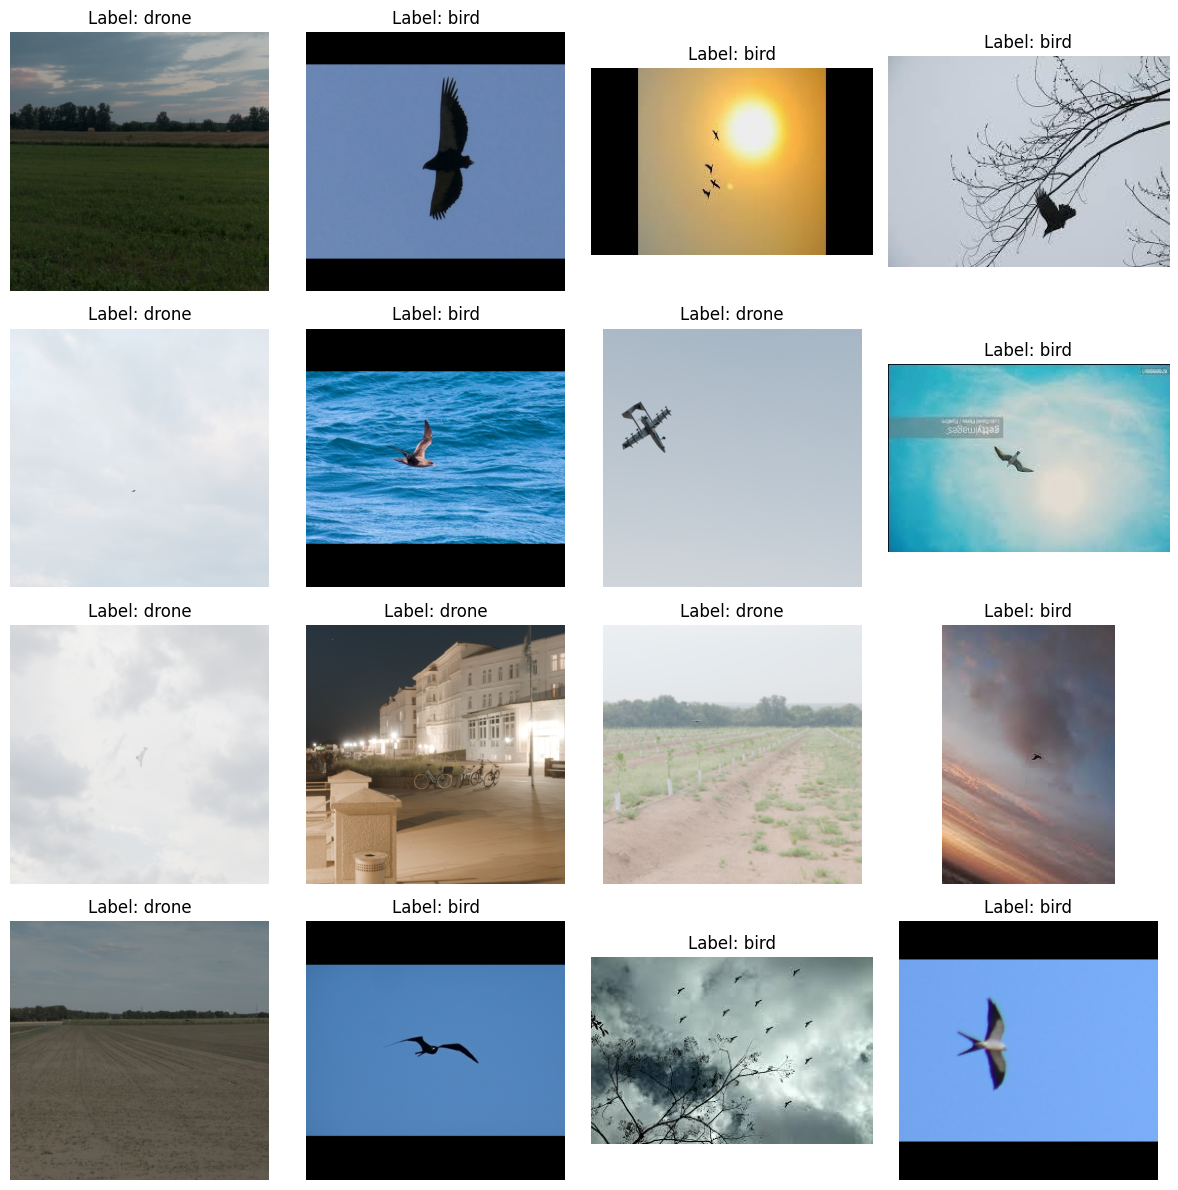

In [ ]:
def show_sample(df):
    _, ax = plt.subplots(4,4,figsize=(12,12))
    ax = ax.flatten()
    random_images = np.random.choice(df['Image Path'].values,16)
    for i in range(len(random_images)):
        img_path = random_images[i]
        ax[i].imshow(plt.imread(img_path))
        ax[i].axis('off')
        ax[i].set_title(f'Label: {img_path.split('/')[-2]}')
        
    plt.tight_layout()

show_sample(train_df)

In [ ]:
def get_transforms(size=IMG_SIZE, apply_on_train=False):
    """
    Build a transform pipeline for training or validation/test.

    Args:
        size: target square image size in pixels
        apply_on_train: if True, adds augmentation steps before normalization

    Returns:
        v2.Compose transform pipeline
    """
    base = [
        v2.Resize((size, size)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ]

    augmentation = [
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(45),
        v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        v2.RandomApply(
            [v2.GaussianBlur(kernel_size=3)],
            p=0.15),
        v2.RandomGrayscale(p=0.1), 
        v2.RandomPerspective(p=0.2),
    ]

    # ImageNet mean/std normalization (required for pretrained models)
    tail = [v2.Normalize(MEAN_NORM, STD_NORM)]

    if apply_on_train:
        return v2.Compose(base + augmentation + tail)
    return v2.Compose(base + tail)

In [ ]:
train_ds = DBDataset(train_df,get_transforms(IMG_SIZE,True))
val_ds = DBDataset(val_df,get_transforms(IMG_SIZE))
test_ds = DBDataset(test_df,get_transforms(IMG_SIZE))

print('Total: ', len(train_ds) + len(val_ds) + len(test_ds))

Total:  22042


In [ ]:
train_dl = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,num_workers=NUM_WORKERS,pin_memory=PIN_MEMORY)
val_dl = DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=PIN_MEMORY)
test_dl = DataLoader(test_ds,batch_size=BATCH_SIZE,shuffle=False,num_workers=NUM_WORKERS,pin_memory=PIN_MEMORY)

In [ ]:
def denorm(imgs):
    """
    Reverse ImageNet normalization so images can be displayed correctly.

    Args:
        imgs: normalized tensor of shape (B, C, H, W) or (C, H, W)

    Returns:
        tensor in [0, 1] range with same shape as input
    """
    mean = torch.tensor(MEAN_NORM).view(1, 3, 1, 1).to(imgs.device)
    std  = torch.tensor(STD_NORM).view(1, 3, 1, 1).to(imgs.device)

    return imgs * std + mean

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000002].


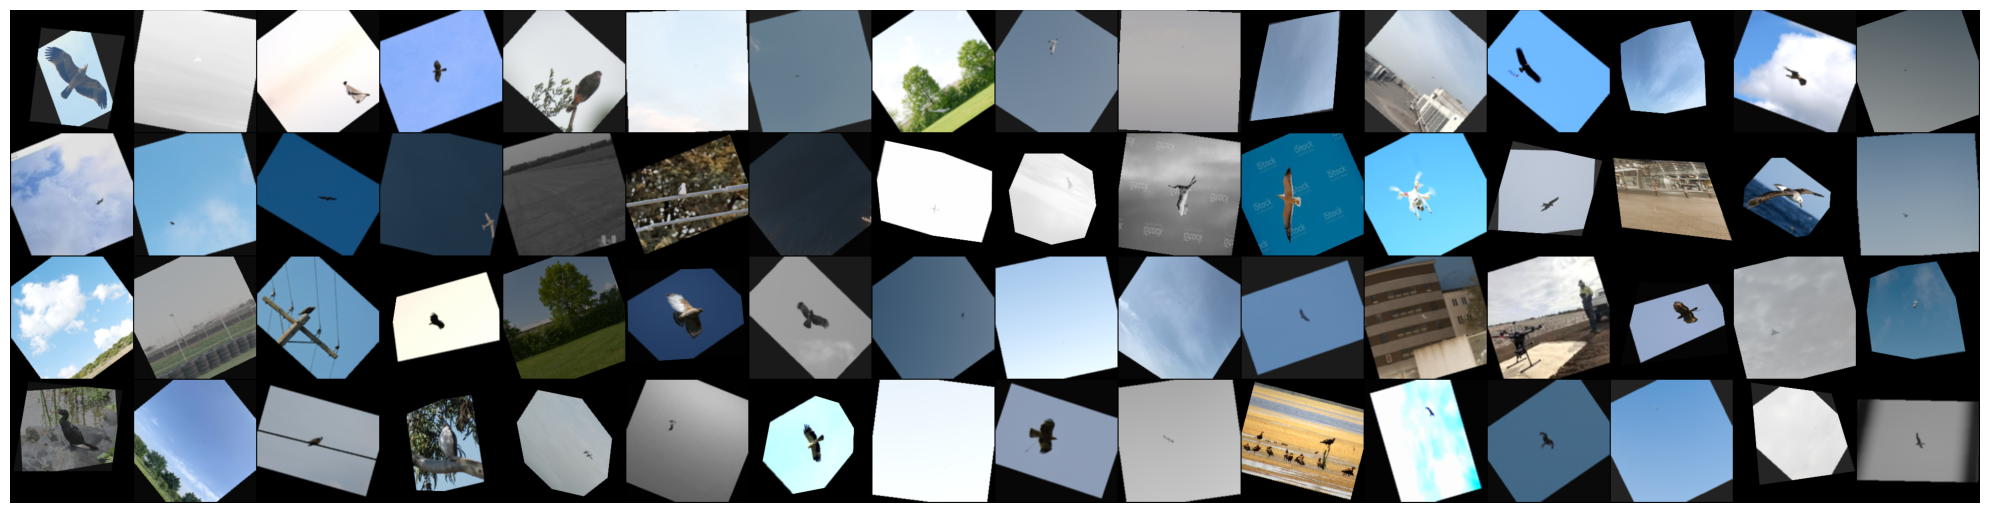

In [ ]:
def show_grid(dl):
    imgs,labels = next(iter(dl))
    plt.figure(figsize=(20,20))
    plt.imshow(make_grid(denorm(imgs),16).permute(1,2,0))
    plt.axis('off')    
    plt.tight_layout()

show_grid(train_dl)

In [ ]:
model = resnet50(ResNet50_Weights.DEFAULT)
model.fc = Linear(model.fc.in_features,NUM_CLASSES)
model = model.to(device)

if torch.cuda.device_count() > 1:
    model = torch.nn.DataParallel(model)


optimizer = AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)

criterion = CrossEntropyLoss()

# OneCycleLR steps every batch, not every epoch
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    steps_per_epoch=len(train_dl),
    epochs=EPOCHS
)

# GradScaler enables mixed precision training
scaler = torch.amp.GradScaler(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 184MB/s] 


In [ ]:
def fit(train_dl, val_dl, apply_earlystopp = True):
    best_loss = float('inf')
    counter = 0
    history = []

    for iter in range(EPOCHS):
        all_train_loss = []
        all_train_acc = []

        model.train()

        for imgs,labels in tqdm(train_dl,f'{iter+1}/{EPOCHS}'):
            imgs = imgs.to(device)
            labels = labels.to(device)

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(imgs)
                loss    = criterion(outputs, labels)

            optimizer.zero_grad()

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            # OneCycleLR must step every batch
            scheduler.step()

            _, preds = torch.max(outputs,dim=1)
            all_train_loss.append(loss.detach().cpu().item())
            all_train_acc.append((preds == labels).detach().cpu().float().mean().item())

        train_loss = sum(all_train_loss) / len(all_train_loss)
        train_acc = sum(all_train_acc) / len(all_train_acc)

        all_val_loss = []
        all_val_acc = []
        
        model.eval()
        with torch.no_grad():
            for imgs,labels in val_dl:
                imgs = imgs.to(device)
                labels = labels.to(device)

                with torch.amp.autocast(device_type='cuda'):
                    outputs = model(imgs)
                    loss    = criterion(outputs, labels)

                _, preds = torch.max(outputs,dim=1)
                all_val_loss.append(loss.detach().cpu().item())
                all_val_acc.append((preds == labels).detach().cpu().float().mean().item())

        val_loss = sum(all_val_loss) / len(all_val_loss)
        val_acc = sum(all_val_acc) / len(all_val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        history.append({
            "train_loss": train_loss, "train_acc": train_acc,
            "val_loss":   val_loss,   "val_acc":   val_acc
        })

        if apply_earlystopp:
            if val_loss < best_loss:
                best_loss = val_loss
                counter  = 0
                torch.save(model.state_dict(), f"best_{model.module.__class__.__name__}_model.pth")
                print("-->> best model saved")
            else:
                counter += 1
                print(f"No improvement ({counter}/{PATIENCE})")
                if counter >= PATIENCE:
                    print("Early stopping triggered.")
                    break

    return history
        

In [ ]:
history = fit(train_dl,val_dl)

1/20: 100%|██████████| 276/276 [03:37<00:00,  1.27it/s]


Train Loss: 0.4746 | Train Acc: 0.8389 | Val Loss: 0.2272 | Val Acc: 0.9481
-->> best model saved


2/20: 100%|██████████| 276/276 [03:11<00:00,  1.44it/s]


Train Loss: 0.1151 | Train Acc: 0.9621 | Val Loss: 0.0585 | Val Acc: 0.9853
-->> best model saved


3/20: 100%|██████████| 276/276 [03:10<00:00,  1.45it/s]


...

Train Loss: 0.0116 | Train Acc: 0.9962 | Val Loss: 0.0126 | Val Acc: 0.9964
No improvement (1/3)


10/20: 100%|██████████| 276/276 [03:07<00:00,  1.47it/s]


Train Loss: 0.0091 | Train Acc: 0.9970 | Val Loss: 0.0353 | Val Acc: 0.9906
No improvement (2/3)


11/20: 100%|██████████| 276/276 [03:07<00:00,  1.47it/s]


Train Loss: 0.0088 | Train Acc: 0.9971 | Val Loss: 0.0182 | Val Acc: 0.9951
No improvement (3/3)
Early stopping triggered.


In [ ]:
name = model.module.__class__.__name__

In [ ]:
def show_curves(model_history, name):
    """
    Plot Loss and Accuracy curves for train and validation splits.
    Saves figure to disk as '<name>_ACCURACY_LOSS_Curves.png'.

    Parameters
    ----------
    model_history : list of dicts | keys: train_loss, val_loss, train_acc, val_acc
    name          : str | model name used in title and filename
    """
    train_loss = [x["train_loss"] for x in model_history]
    val_loss   = [x["val_loss"]   for x in model_history]
    train_acc  = [x["train_acc"]  for x in model_history]
    val_acc    = [x["val_acc"]    for x in model_history]

    _, ax = plt.subplots(1, 2, figsize=(14, 5))

    ax[0].plot(train_loss, label="Train",      linewidth=2)
    ax[0].plot(val_loss,   label="Validation", linewidth=2, linestyle="--")
    ax[0].set_title(f"{name} Loss Over Epochs", fontsize=13, fontweight="bold")
    ax[0].set_ylabel("Loss")
    ax[0].set_xlabel("Epoch")
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    ax[1].plot(train_acc, label="Train",      linewidth=2)
    ax[1].plot(val_acc,   label="Validation", linewidth=2, linestyle="--")
    ax[1].set_title(f"{name} Accuracy Over Epochs", fontsize=13, fontweight="bold")
    ax[1].set_ylabel("Accuracy")
    ax[1].set_xlabel("Epoch")
    ax[1].legend()
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'Results/{name}_ACCURACY_LOSS_Curves.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
def Show_CMwithClassReport(all_labels, all_preds, name):
    """Print classification report and plot confusion matrix."""
    cm = confusion_matrix(np.array(all_labels), np.array(all_preds))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=LABELS,
                yticklabels=LABELS)
    plt.title(f'{name} Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'Results/{name}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(classification_report(all_labels, all_preds, target_names=LABELS))


In [ ]:
def predict(model):
    """Run inference on the test set and return true labels and predictions."""
    all_labels, all_preds = [], []

    model.eval()
    with torch.no_grad():
        for imgs, labels in test_dl:
            imgs   = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.detach().cpu().tolist())
            all_labels.extend(labels.detach().cpu().tolist())

    return all_labels, all_preds
